**Goal:** model each class as a Gaussian, watch LDA draw a straight boundary and QDA draw a
curved one, and find out when the curve is worth it. Pairs with the concept note
[Gaussian Discriminant Analysis](l06_concept_gaussian_discriminant_analysis.qmd).

> **Previously:** L05 -- Linear Models for Classification  |  **Next:** L07 -- Naive Bayes

> This page is the read-only view. To run the lab, open the notebook
> (`l06_lab_gaussian_discriminant_analysis.ipynb`) -- in Colab via the badge on the concept
> page, or locally.

## Scenario

An agricultural station near Mayaguez sorts mangoes into two cultivars: the local mayaguezano
(smaller, lighter) and the export favorite keitt (longer, heavier). Each fruit gets two quick
measurements -- length (cm) and weight (g). Crucially, longer fruit run heavier *within* each
cultivar too, so the two features are **correlated** -- exactly the structure a Gaussian's
covariance can capture.

The data below is **synthetic** (fixed seed, identical for everyone) with fictionalized but
plausible values.

## Setup

The setup is **two cells** (the pattern every lab uses). The first only installs; the second
imports, seeds the generator, and builds the data.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, numpy and matplotlib, so this is effectively a no-op there.
%pip install -q scikit-learn
# local, in a terminal (not in the notebook):  uv add scikit-learn numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, DATA (safe to re-run without re-installing)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

rng = np.random.default_rng(7)           # fixed seed: identical data for everyone
n = 90                                   # fruits per cultivar

len_m = rng.normal(10.5, 1.2, n)         # mayaguezano lengths
len_k = rng.normal(12.0, 1.4, n)         # keitt lengths
mangoes = pd.DataFrame({
    "length_cm": np.concatenate([len_m, len_k]).round(2),
    "weight_g":  np.concatenate([410 + 10*(len_m - 10.5) + rng.normal(0, 70, n),
                                 560 + 10*(len_k - 12.0) + rng.normal(0, 70, n)]).round(0),
    "cultivar":  ["mayaguezano"] * n + ["keitt"] * n,
})

from sklearn.model_selection import train_test_split

X = mangoes[["length_cm", "weight_g"]]
y = mangoes["cultivar"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=7, stratify=y)
print(len(X_train), "training fruits /", len(X_test), "test fruits")

135 training fruits / 45 test fruits


~~~text
135 training fruits / 45 test fruits
~~~

Two small plot helpers: one draws a class's 2-sigma Gaussian ellipse (its fitted "portrait"),
the other draws a trained model's decision boundary.

In [3]:
def class_ellipse(ax, points, **kw):
    """Draw the 2-sigma covariance ellipse of a class's points (the fitted Gaussian)."""
    mu = points.mean(axis=0)
    cov = np.cov(points, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)                          # ascending eigenvalues
    angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))    # orientation of the major axis
    width, height = 2 * 2 * np.sqrt(vals[1]), 2 * 2 * np.sqrt(vals[0])
    ax.add_patch(Ellipse(tuple(mu), width, height, angle=angle, fill=False, linewidth=2, **kw))

def plot_boundary(ax, model, Xdf, **kw):
    """Draw where the model switches its prediction across the feature plane."""
    f0, f1 = Xdf.columns
    g0 = np.linspace(Xdf[f0].min() - 0.5, Xdf[f0].max() + 0.5, 300)
    g1 = np.linspace(Xdf[f1].min() - 0.5, Xdf[f1].max() + 0.5, 300)
    xx, yy = np.meshgrid(g0, g1)
    grid = pd.DataFrame({f0: xx.ravel(), f1: yy.ravel()})
    classes = list(model.classes_)
    Z = np.array([classes.index(v) for v in model.predict(grid)]).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2, **kw)

## Step 1: LDA -- A Gaussian per Class, a Line Between Them

Linear discriminant analysis models each cultivar as a Gaussian with a **shared** covariance and
classifies by Bayes' rule. Fit it and read the same first test fruit the concept note used:

In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
print("class order:", lda.classes_)
print(f"LDA test accuracy: {lda.score(X_test, y_test):.3f}")

fruit = X_test.iloc[[0]]
print("mystery fruit:", X_test.iloc[0].to_dict(), "| true:", y_test.iloc[0])
print("LDA posterior:", np.round(lda.predict_proba(fruit)[0], 3))

class order: ['keitt' 'mayaguezano']
LDA test accuracy: 0.933
mystery fruit: {'length_cm': 11.8, 'weight_g': 544.0} | true: keitt
LDA posterior: [0.948 0.052]


~~~text
class order: ['keitt' 'mayaguezano']
LDA test accuracy: 0.933
mystery fruit: {'length_cm': 11.8, 'weight_g': 544.0} | true: keitt
LDA posterior: [0.948 0.052]
~~~

The posterior follows `class order`: 0.948 keitt vs 0.052 mayaguezano -- a confident, correct
call. Now make the model visible: each class as a tilted Gaussian ellipse (the tilt *is* the
length-weight correlation), with LDA's straight boundary between them.

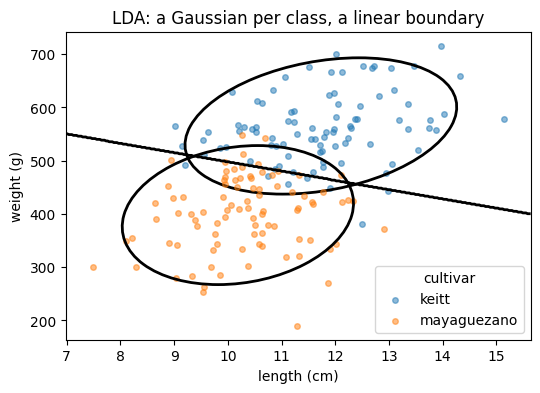

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for cultivar in sorted(y.unique()):
    pts = X[y == cultivar]
    ax.scatter(pts["length_cm"], pts["weight_g"], label=cultivar, alpha=0.5, s=16)
    class_ellipse(ax, X_train[y_train == cultivar].to_numpy())
plot_boundary(ax, lda, X_train)
ax.set_xlabel("length (cm)")
ax.set_ylabel("weight (g)")
ax.legend(title="cultivar")
ax.set_title("LDA: a Gaussian per class, a linear boundary")
plt.show()

Each ellipse is that cultivar's fitted Gaussian; both tilt the same way (shared covariance), and
the boundary between them comes out straight. That straightness is the LDA assumption at work.

## Step 2: QDA and Logistic -- completion problem

Give each class its **own** covariance and you get QDA, whose boundary may curve. And logistic
regression (L04) draws a linear boundary discriminatively, for comparison. Same split, same test
fruits -- complete the marked lines:

In [6]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

# Uncomment and complete the marked lines:
# qda = QuadraticDiscriminantAnalysis().fit(____, ____)          # fit on the TRAINING data
# logreg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
# print(f"LDA test accuracy:      {lda.score(X_test, y_test):.3f}")
# print(f"QDA test accuracy:      {qda.score(X_test, y_test):.3f}")
# print(f"logistic test accuracy: {logreg.score(____, ____):.3f}")

<details><summary>Expected Output</summary>

~~~text
LDA test accuracy:      0.933
QDA test accuracy:      0.933
logistic test accuracy: 0.933
~~~

All three tie at 0.933. The two cultivars have roughly the same covariance, so QDA's freedom to
curve buys nothing here -- its boundary stays nearly straight -- and LDA's generative line lands
in the same place as logistic's discriminative one. When covariances are equal, the simplest line
is enough; Exercise 1 builds the case where it is not.
</details>

## Your Turn

### Exercise 1 -- When you need the curve

Build two classes whose covariances genuinely **differ** -- one spread wide along x, the other
wide along y, with overlapping centers -- and compare LDA against QDA. Which one can separate them?

**Hint:** `rng2 = np.random.default_rng(3)`; build `c0 = rng2.normal([0,0], [2.4,0.6], (150,2))` and `c1 = rng2.normal([1.5,1.5], [0.6,2.4], (150,2))` (the second tuple is the per-axis standard deviation `[sd_x, sd_y]`); then `Xu = np.vstack([c0, c1])` and `yu = np.array([0]*150 + [1]*150)` (matching that row order); split with `train_test_split(Xu, yu, test_size=0.25, random_state=3, stratify=yu)`; fit `LinearDiscriminantAnalysis` and `QuadraticDiscriminantAnalysis` and score each on the test split; optionally draw both boundaries with `plot_boundary`.

In [7]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
unequal-covariance data -- LDA: 0.680  QDA: 0.880
~~~

Now the covariances point in different directions, so the best boundary curves -- and only QDA can
draw it. LDA's single straight line is stuck at 0.680 while QDA reaches 0.880. This is the whole
reason QDA exists: per-class covariances buy a quadratic boundary, which pays off precisely when
the classes are shaped differently. (The cost, from the concept note: QDA estimates far more
numbers, so it needs enough data per class to do it well.)
</details>

### Exercise 2 -- The generative and discriminative lines agree

Back on the mangoes: LDA reached its linear boundary by modeling each class (generative); logistic
regression reached one by optimizing the boundary directly (discriminative). Do they actually
label the test fruits the same way?

**Hint:** compare `lda.predict(X_test)` with `logreg.predict(X_test)` element-wise and count the matches.

In [8]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
LDA and logistic agree on 45 of 45 test fruits
~~~

Every single test fruit, the same label -- two philosophies, one line. On clean, roughly-Gaussian
data with a shared covariance, the generative route (LDA) and the discriminative route (logistic)
converge on the same answer. They part ways when the Gaussian assumption is wrong, or when data is
scarce and each model's assumptions start to matter.
</details>

## Summary

- A generative classifier models each class and applies Bayes' rule; **GDA** models each class as
  a Gaussian, whose covariance captures the feature correlation a single spread would miss.
- **LDA** shares one covariance across classes and draws a **linear** boundary; **QDA** gives each
  class its own and draws a **quadratic** one. On the mangoes both tied at 0.933.
- The curve earns its keep only when the classes are shaped differently: on unequal-covariance
  data QDA reached 0.880 where LDA was stuck at 0.680.
- LDA's line and logistic regression's line agreed on all 45 test fruits -- the generative and
  discriminative routes to a linear boundary coincide on well-behaved data.
- Next (L07): the other generative classifier -- **Naive Bayes** -- which keeps Bayes' rule but
  trades GDA's full covariance for an assumption that the features are independent.